In [1]:
# 성인 남녀 얼굴 이미지 분류 (이진) - data는 구글 드라이브에 있음
# 파일명에 lable로 사용할 힌트가 있음

from google.colab import drive
drive.mount('/content/drive')

import os, cv2, numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

base_dir = '/content/drive/MyDrive'

image_dir = None

for root, dirs, files in os.walk(base_dir):
  if os.path.basename(root) == 'person_img':
    image_dir = root
    break

print('image_dir :', image_dir)

x, y = [], []

# 레이블 구하기 : 30_0_0_20170120220636164.jpg
# gender = int(파일명.split('_')[1]) 0 -> male, 1-> female

for file in os.listdir(image_dir):
  try:
    gender = int(file.split('_')[1])
    img_path = os.path.join(image_dir, file)
    img = cv2.imread(img_path)

    if img is None:
      continue

    img = cv2.resize(img, (64, 64)) # 크기 조정
    x.append(img)
    y.append(gender)
  except:
    continue

print(x[0])
print(y[0])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
image_dir : /content/drive/MyDrive/person_img-20260512T024720Z-3-001/person_img
[[[252 251 253]
  [207 210 215]
  [181 187 192]
  ...
  [ 78  99 100]
  [240 254 255]
  [247 252 253]]

 [[249 253 254]
  [208 213 217]
  [188 198 201]
  ...
  [ 95 109 111]
  [245 253 254]
  [248 252 253]]

 [[247 254 254]
  [205 213 217]
  [180 191 195]
  ...
  [ 91 101 104]
  [245 252 254]
  [244 252 252]]

 ...

 [[251 253 247]
  [119 118 116]
  [ 34  29  30]
  ...
  [ 29  27  26]
  [254 253 252]
  [252 250 249]]

 [[254 255 250]
  [122 121 119]
  [ 32  27  28]
  ...
  [ 29  27  26]
  [254 253 252]
  [252 250 249]]

 [[254 254 248]
  [118 120 116]
  [ 27  27  26]
  ...
  [ 25  26  24]
  [253 255 254]
  [252 253 253]]]
0


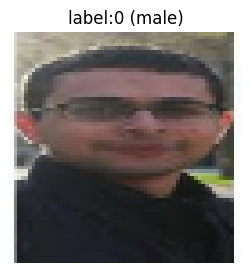

In [2]:
# 첫번째 이미지 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 3))
img_rgb = cv2.cvtColor(x[0], cv2.COLOR_BGR2RGB) # matplotlib: RGB , opencv:BGR
plt.imshow(img_rgb)
plt.title(f"label:{y[0]} ({'male' if y[0] == 0 else 'female'})")
plt.axis('off')
plt.show()

In [3]:
# 정규화
x = np.array(x) / 255.0
y = np.array(y)

# train/ test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)

(102, 64, 64, 3) (26, 64, 64, 3)


In [4]:
# model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten,Dense, Input

model = Sequential([
    Input(shape=(64,64, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [5]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=2)

loss, acc = model.evaluate(x_test, y_test)
print(f'test acc : {acc:.4f}')

Epoch 1/20
3/3 - 6s - 2s/step - accuracy: 0.7284 - loss: 0.7433 - val_accuracy: 0.4762 - val_loss: 0.7027
Epoch 2/20
3/3 - 0s - 34ms/step - accuracy: 0.8148 - loss: 0.6183 - val_accuracy: 0.7619 - val_loss: 0.6060
Epoch 3/20
3/3 - 0s - 32ms/step - accuracy: 0.7284 - loss: 0.5383 - val_accuracy: 0.7619 - val_loss: 0.6562
Epoch 4/20
3/3 - 0s - 33ms/step - accuracy: 0.7284 - loss: 0.5070 - val_accuracy: 0.6190 - val_loss: 0.6803
Epoch 5/20
3/3 - 0s - 31ms/step - accuracy: 0.8642 - loss: 0.4984 - val_accuracy: 0.7143 - val_loss: 0.6534
Epoch 6/20
3/3 - 0s - 32ms/step - accuracy: 0.8025 - loss: 0.4199 - val_accuracy: 0.7143 - val_loss: 0.6969
Epoch 7/20
3/3 - 0s - 32ms/step - accuracy: 0.8765 - loss: 0.3650 - val_accuracy: 0.6667 - val_loss: 0.7547
Epoch 8/20
3/3 - 0s - 33ms/step - accuracy: 0.9136 - loss: 0.3133 - val_accuracy: 0.7143 - val_loss: 0.9744
Epoch 9/20
3/3 - 0s - 30ms/step - accuracy: 0.8148 - loss: 0.3365 - val_accuracy: 0.5714 - val_loss: 0.9313
Epoch 10/20
3/3 - 0s - 31ms/st

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
예측값 :  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
실제값 :  [0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1]


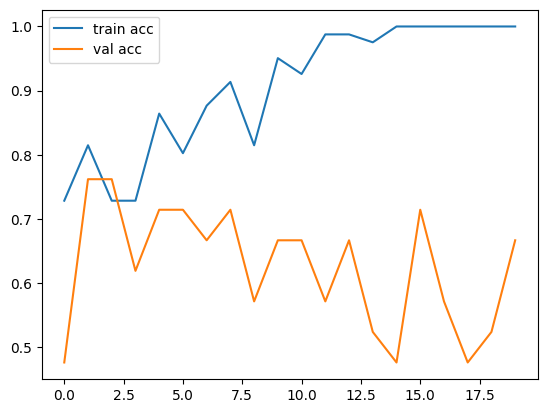

In [10]:
# 예측
pred = model.predict(x_test)
print('예측값 : ',  (pred >= 5).astype(int).reshape(-1))
print('실제값 : ', y_test)

# acc 시각화
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step


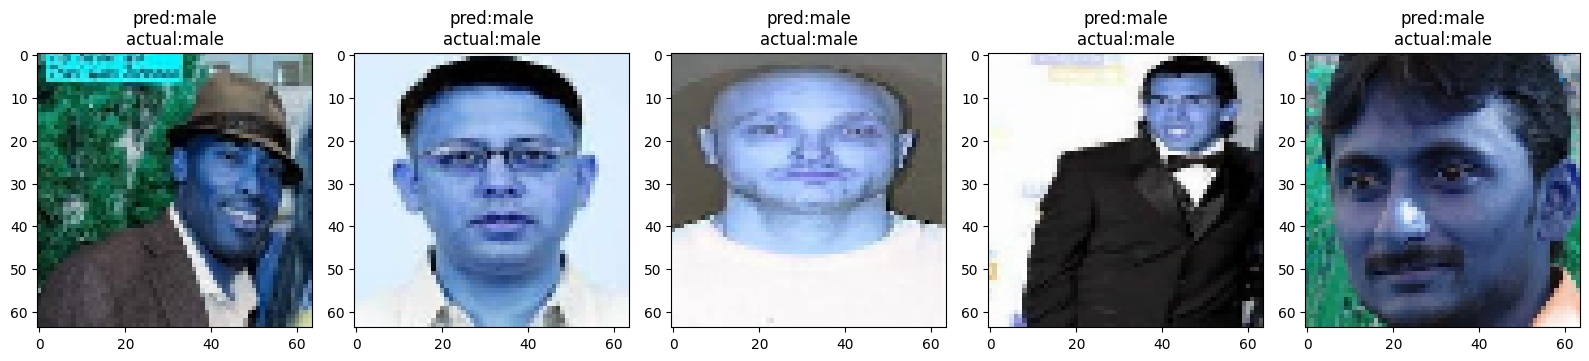

In [12]:
# 5개의 이미지로 분류 예측 시각화 5개의 이미지로 분류 예측 시각화
pred = model.predict(x_test[:5])
pred_classes = (pred >= 0.5).astype(int).reshape(-1)
true_classes = y_test[:5]

plt.figure(figsize=(16, 4))
for i in range(5):
  plt.subplot(1, 5, i + 1)
  plt.imshow(x_test[i])

  is_correct = pred_classes[i] == true_classes[i]
  label = 'female' if true_classes[i] == 1 else 'male'
  prediction = 'female' if true_classes[i] == 1 else 'male'
  title_color = 'black' if is_correct else 'red'
  plt.title(f'pred:{prediction}\nactual:{label}', color=title_color)
  plt.axis=('off')
plt.tight_layout()
plt.show()

# 현재 모델은 학습데이터 부족으로 좋은 결과를 기대하기 어렵다.